# Line Selection Model: which maize lines should we advance in 2008?

This notebook explains, step by step, how we go from raw field data to a ranked list of 2008 lines, and how good that list is.

**The decision (from the scenario):** it's January 2008, and field plots were cut. We have about 16,000 new lines (157 families) about to be tested, and we must choose which ones deserve the limited plots.

**What we can use:** field results from 2000 to 2007, the genotypes of every line (including the 2008 ones), each family's parents, and the tester each family was crossed to.

**What we can't use:** anything measured in 2008. The 2008 yields sit in the files, but we only use them at the very end, as an answer key to score ourselves.

### The plan in one picture

```
 Raw plots (yield of line L at site S)
        |
        |  STAGE 1  (etapa1, s04): mixed model
        v
 Line value = FAMILY value + WITHIN-FAMILY deviation      <- "true-ish" values for past lines
        |
        |  STAGE 2  (etapa2, s06): genomic prediction
        v
 Predicted FAMILY value   (parents' history + parents' genotypes + tester)
 Predicted WITHIN value   (which parent each sibling inherited each chromosome piece from)
        |
        v
 Predicted line value +/- uncertainty  ->  2008 ranking  ->  which lines get plots
```

**How to rerun everything:**
1. `bash etapa1/run_stage1.sh "<path>/Simplified Hackathon Dataset V3" artifacts`, about 5 to 8 minutes
2. `bash etapa2/run_stage2.sh "<path>/Simplified Hackathon Dataset V3" artifacts`, about 5 minutes

This notebook only reads the saved results in `etapa2/resultados`, so it opens and runs in seconds.

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)
RES = 'resultados'
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
INK, MUTED = '#0b0b0b', '#898781'
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True, 'grid.color': '#e6e5e0',
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'legend.frameon': False, 'axes.axisbelow': True})

scores_all = pd.read_csv(f'{RES}/stage2_scores.csv')
scores = scores_all[scores_all.trait == 'YLD_BE']          # yield (the file also holds moisture)
strat = pd.read_csv(f'{RES}/selection_strategies.csv')
choices = json.load(open(f'{RES}/stage2_choices.json'))
P = pd.read_parquet(f'{RES}/predictions_all_years.parquet')
R = pd.read_csv(f'{RES}/ranking_2008_lines.csv')
F = pd.read_csv(f'{RES}/ranking_2008_families.csv')
vc = pd.read_csv('../etapa1/resultados/varcomp.csv')
print(f'{len(P):,} line predictions (2004-2008), {len(R):,} lines to rank in 2008, {len(F)} families in 2008')

95,859 line predictions (2004-2008), 15,968 lines to rank in 2008, 157 families in 2008


## 1. Why we need a model at all: the environment is louder than the genetics

A raw yield number mixes three things:

- **the site and year** (good soil, good rain), which is about 60% of the variation
- **the line's genetics**, which is what we want, and only about 10%
- **plot noise** (one plot per line per site)

If we compared raw yields, a mediocre line planted at a great site would look like a star. The model's first job is to pull these apart.

## 2. Stage 1: the mixed model (your team's `etapa1/s04_line_values.py`)

### 2a. Yield = site effect + line effect + noise

For each cluster, every plot is described as:

**yield of line L at site S = site effect(S) + line effect(L) + noise**

- The **site effect** is how good that site was that year for everyone.
- The **line effect** is how much better or worse this line is than others grown at the same sites. This is the line's **BLUE** (best linear unbiased estimate).
- **Noise** gets its own size at each site. Messy trials count less, which is the "heterogeneous residual variance" part.

The model also drops extreme plots (outliers) and sites where lines' results don't agree with their results elsewhere (bad trials).

### 2b. Splitting each line into "family" + "sibling deviation"

Here is the key design fact the team found: **about 90% of the time, a site tests only one family.** So a family's average is tangled up with how good its particular sites were. Siblings, on the other hand, always share the same sites, so comparing a line to its own siblings is very clean.

So each line's value is split in two:

| Part | Meaning | Name in files | How reliable? |
|---|---|---|---|
| Family value | How good the whole family is | `POP_BLUE` | Moderate (family x site noise) |
| Within-family deviation | How much better this line is than its siblings | `DEV` | Clean; site effects cancel |
| **Line value** | The sum: what we select on | `BLUE` | |

### 2c. What the variance components say

In [2]:
v = vc[(vc.TRAIT == 'YLD_BE') & vc.YEAR.between(2001, 2007)]
summary = v.groupby('CLUSTER')[['S2_G_BETWEEN', 'S2_G_WITHIN', 'H2_LINE_WITHIN', 'POP_MEAN_REL']].median().round(2)
summary.columns = ['Genetic variance BETWEEN families', 'Genetic variance WITHIN families',
                   'Heritability of a line vs its siblings', 'Reliability of a family average']
summary.T

CLUSTER,C1,C2
Genetic variance BETWEEN families,123.28,101.33
Genetic variance WITHIN families,36.00,27.57
Heritability of a line vs its siblings,0.45,0.42
Reliability of a family average,0.70,0.70


**How to read it:**

- **Most genetic variation is between families** (about 110 vs 30). Picking the right families matters most.
- **Within a family**, a line's observed value is only about 45% signal (heritability about 0.45). Even a perfect model can't correlate better than about 0.67 with the observed values, because the "truth" we score against is itself noisy.
- These numbers set the ceiling for everything that follows.

## 3. Stage 2: predicting brand-new lines (`etapa2/s06_stage2.py`)

The 2008 lines have never been in a field, so they have no BLUE. We predict each of the two parts.

### 3a. Family part: "tell me who your parents are"

Three predictors, built by the team in `etapa1/s05` (the "baselines"):

| Model | Idea |
|---|---|
| **B1** Parent history | Average past performance of families that used the same parents (their GCA, general combining ability) |
| **B2** B1 + tester | Also adds how good the tester has been historically |
| **B3** Genomic family model | Ridge regression on the parents' **genotypes** (expected family genotype) + tester. Works even when a parent has little history |

Stage 2 picks the best option (or an average of two) for each cluster, judged on 2004 to 2007 only:

In [3]:
pd.DataFrame({C: {'Family model chosen': v['family_model'],
                  'Within model penalty (lambda)': v['W1_lambda'],
                  'Weight on parent-segment model W2': v['W2_weight']} for C, v in choices['yield'].items()})

,C1,C2
Family model chosen,B3,B1+B3
Within model penalty (lambda),3000,10000
Weight on parent-segment model W2,0.0,0.25


### 3b. Within-family part: "which chromosome pieces did you inherit?"

This is the new piece. All siblings share the same two parents, so what makes one better than another is **which parent it inherited each chromosome segment from**.

- **W1: genomic ridge regression (rrBLUP).** We take every line's 2,911 marker genotypes, subtract its family's average genotype (so only the "which parent did you get here" part remains), and learn one small effect per marker from the 2000 to 2007 lines. Ridge regression shrinks all effects toward zero, which is the standard way to handle thousands of markers with noisy data. It's mathematically the same as a GBLUP mixed model with markers as random effects.
- **W2: parent-segment model.** An effect for each *parent's* 10 cM chromosome segment. It helps only when parents recur, so it's used with a small weight in C2 and not at all in C1.

The final prediction for a 2008 line is simply **family prediction + within-family prediction**.

## 4. How we test it honestly: forward validation

We mimic the real January decision every year:

| Test year | Train on | Predict |
|---|---|---|
| 2004 | 2000 to 2003 | the new 2004 families |
| 2005 | 2000 to 2004 | the new 2005 families |
| 2006 | 2000 to 2005 | ... |
| 2007 | 2000 to 2006 | ... |
| **2008 (holdout)** | 2000 to 2007 | the 2008 families, **scored once at the end** |

All model choices were made on 2004 to 2007. 2008 was never used to tune anything.

**Metrics:**

- **r overall**: correlation between predicted and observed line values.
- **r between families**: same, using family averages.
- **rho within families**: rank agreement among siblings (0 for any family-only model, since those give every sibling the same number).
- **% of max gain**: if we advance our top 10%, how much of the yield advantage do we capture, compared with picking the true top 10%?

In [4]:
S = scores[scores.model != 'Within-family model on DEV'].copy()
S['split'] = np.where(S.holdout, '2008 holdout', '2004-07 validation')
show = ['B1 parent history (family only)', 'B3 genomic family model (family only)', 'Stage 2 total (family + within)']
S[S.model.isin(show)].pivot_table(index=['cluster', 'model'], columns='split',
    values=['r_overall', 'r_between_pops', 'rho_within_pops']).round(3)

r_between_pops                       r_overall                 rho_within_pops             
split                                         2004-07 validation 2008 holdout 2004-07 validation 2008 holdout 2004-07 validation 2008 holdout
cluster model                                                                                                                                
C1      B1 parent history (family only)                    0.292        0.377              0.231        0.321                NaN          NaN
        B3 genomic family model (family only)              0.461        0.341              0.371        0.331                NaN          NaN
        Stage 2 total (family + within)                    0.461        0.341              0.393        0.344              0.238        0.175
C2      B1 parent history (family only)                    0.345        0.332              0.295        0.279                NaN          NaN
        B3 genomic family model (family only)              0.471        0.710              0.401        0.646                NaN          NaN
        Stage 2 total (family + within)                    0.492        0.703              0.426        0.636              0.234        0.187

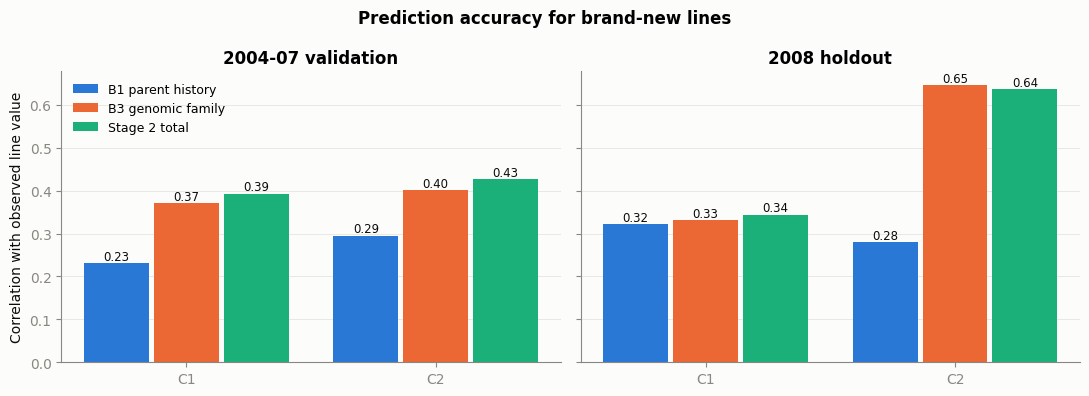

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
labels = {'B1 parent history (family only)': 'B1 parent history', 'B3 genomic family model (family only)': 'B3 genomic family',
          'Stage 2 total (family + within)': 'Stage 2 total'}
for ax, split in zip(axes, ['2004-07 validation', '2008 holdout']):
    d = S[(S.split == split) & S.model.isin(show)].groupby(['cluster', 'model']).r_overall.mean().unstack()[show]
    x = np.arange(len(d)); w = 0.26
    for i, m in enumerate(show):
        bars = ax.bar(x + (i - 1) * (w + 0.02), d[m], w, color=COLORS[i], label=labels[m])
        for b in bars: ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008, f'{b.get_height():.2f}', ha='center', fontsize=8.5, color=INK)
    ax.set_xticks(x); ax.set_xticklabels(d.index); ax.set_title(split); ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Correlation with observed line value'); axes[0].legend(fontsize=9, loc='upper left')
plt.suptitle('Prediction accuracy for brand-new lines', fontweight='bold'); plt.tight_layout(); plt.show()

**What this shows:**

- The genomic family model (B3) beats parent history alone (B1) in validation for both clusters.
- Stage 2 is the best model in validation for both clusters, and within 0.01 of the best in 2008, because it adds sibling ranking on top of the family prediction.
- 2008 was a hard year for C1 and a very good one for C2. Year-to-year swings like this are normal, and exactly why we validate on several years.

### Sibling ranking: the part the baselines couldn't do

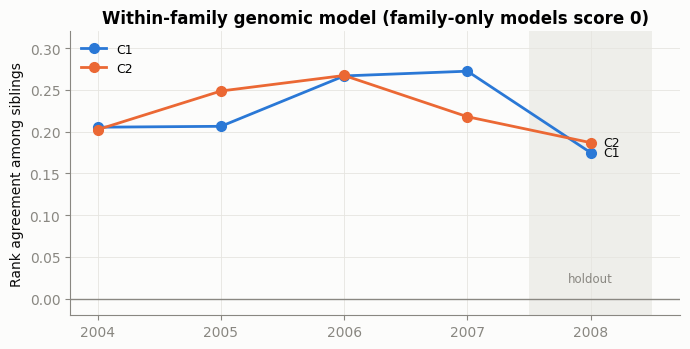

In [6]:
W = scores[scores.model == 'Within-family model on DEV'].pivot_table(index='year', columns='cluster', values='rho_within_pops')
fig, ax = plt.subplots(figsize=(7, 3.6))
for i, c in enumerate(W.columns):
    ax.plot(W.index, W[c], marker='o', ms=7, lw=2, color=COLORS[i], label=c)
    ax.text(W.index[-1] + 0.1, W[c].iloc[-1], c, color=INK, va='center', fontsize=9)
ax.axhline(0, color=MUTED, lw=1); ax.axvspan(2007.5, 2008.5, color='#e6e5e0', alpha=0.6, lw=0)
ax.text(2008, 0.02, 'holdout', ha='center', fontsize=8.5, color=MUTED)
ax.set_ylim(-0.02, 0.32); ax.set_xticks(W.index); ax.set_ylabel('Rank agreement among siblings')
ax.set_title('Within-family genomic model (family-only models score 0)'); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

Rank agreement of about 0.2 to 0.27 against noisy observations corresponds to roughly 0.3 to 0.4 against the true genetic values (dividing by the square root of the within-family heritability). That's useful: it separates the best siblings from the worst ones better than chance, before any field plot.

## 5. From predictions to a decision: how to pick lines

A single sorted list lets within-family noise shuffle the top. Breeders usually pick in two steps, and so do we:

1. **Choose the best families** (top 30%) using the family prediction.
2. **Inside each chosen family, take the best siblings** using the within-family prediction.

Besides working well, this keeps many families in the program, which protects genetic diversity.

In [7]:
st = strat.assign(split=np.where(strat.year == 2008, '2008 holdout', '2004-07 validation'))
order = ['Random', 'Family prediction only', 'Total prediction, one list', 'Two-step: top 30% families, best siblings']
tab = st.pivot_table(index='strategy', columns=['split', 'cluster'], values='gain_pct_of_max').reindex(order).round(1)
tab

split                                     2004-07 validation       2008 holdout      
cluster                                                   C1    C2           C1    C2
strategy                                                                             
Random                                                   0.0  -0.4          2.3  -0.1
Family prediction only                                  22.9  30.1         24.7  58.8
Total prediction, one list                              28.6  30.2         15.6  57.4
Two-step: top 30% families, best siblings               35.9  30.6         27.4  50.9

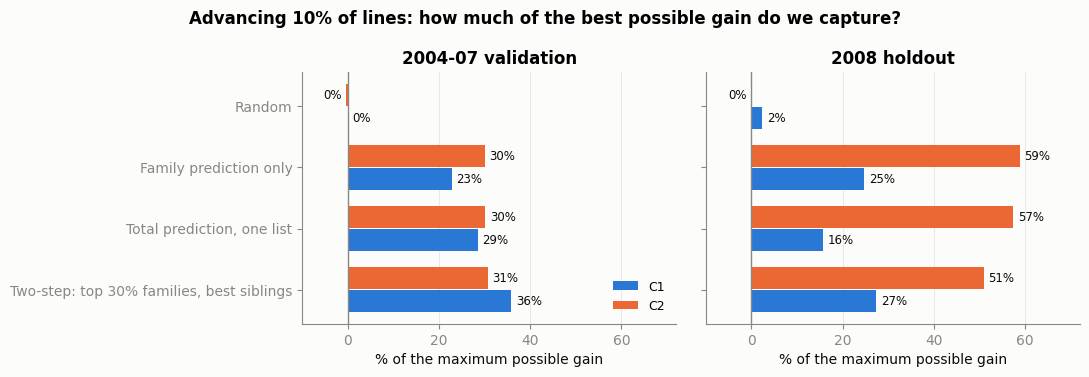

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, split in zip(axes, ['2004-07 validation', '2008 holdout']):
    d = st[st.split == split].groupby(['strategy', 'cluster']).gain_pct_of_max.mean().unstack().reindex(order[::-1])
    y = np.arange(len(d)); h = 0.36
    for i, c in enumerate(d.columns):
        bars = ax.barh(y + (i - 0.5) * (h + 0.02), d[c], h, color=COLORS[i], label=c)
        for b in bars:
            v = b.get_width(); ax.text(v + (1 if v >= 0 else -1), b.get_y() + b.get_height()/2, f'{v:.0f}%'.replace('-0%', '0%'), va='center', ha='left' if v >= 0 else 'right', fontsize=8.5, color=INK)
    ax.set_yticks(y); ax.set_yticklabels(d.index if ax is axes[0] else []); ax.axvline(0, color=MUTED, lw=1)
    ax.set_title(split); ax.set_xlabel('% of the maximum possible gain'); ax.grid(axis='y', visible=False)
axes[0].legend(fontsize=9, loc='lower right'); axes[0].set_xlim(-10, 72)
plt.suptitle('Advancing 10% of lines: how much of the best possible gain do we capture?', fontweight='bold'); plt.tight_layout(); plt.show()

**Reading it honestly:**

- Every model beats random selection (about 0%) by a wide margin.
- The two-step strategy is the most **consistent**: best in C1 in both periods, and about tied in C2 validation.
- In the C2 2008 holdout, family-only selection did better (59% vs 51%). C2's family predictions were unusually accurate that year, so concentrating on the top families paid off.
- The single-list approach is the least stable.

We recommend the two-step strategy as the default. The family share (30%) is one setting the breeder can adjust.

## 6. How sure are we? Uncertainty for every line

Each line gets a prediction SD from how wrong we were in 2004 to 2007:

- **Family error** is larger when the parents have no history. Knowing zero, one or two parents changes it.
- **Within-family error** comes on top.
- A **calibration factor** stretches the SDs so a 90% interval really covered 90% of observed values in 2004 to 2007.

From this we compute **P_TOP10**: the probability that a line truly belongs in the year's top 10%.

In [9]:
u = choices['uncertainty']
fam = pd.Series(u['family_sd']).rename(lambda k: f"{k.split('_')[0]}, {k.split('_')[1]} parent(s) with history")
print('Family-part prediction SD (bu/ac):'); print(fam.round(1).to_string())
print('\nWithin-family SD (bu/ac):', {k: round(v, 1) for k, v in u['within_sd'].items() if k != 'calibration_factor'})
print('Calibration factor:', u['within_sd']['calibration_factor'])

Family-part prediction SD (bu/ac):
C1, 0 parent(s) with history    16.4
C1, 1 parent(s) with history    11.3
C1, 2 parent(s) with history    11.5
C2, 0 parent(s) with history     7.5
C2, 1 parent(s) with history    11.7
C2, 2 parent(s) with history    13.1

Within-family SD (bu/ac): {'C1': 6.1, 'C2': 5.4}
Calibration factor: 1.12


In [10]:
# did the 90% interval hold up in 2008? (needs the 2008 answer key, used only here)
K = pd.read_csv(f'{RES}/ranking_2008_with_answer_key.csv').dropna(subset=['YLD_OBS_BLUE'])
# observed BLUEs carry their own noise; approximate it with the within-family noise level from Stage 1
v8 = vc[(vc.TRAIT == 'YLD_BE') & (vc.YEAR == 2008)].set_index('CLUSTER').PEV_MEAN
tot = np.sqrt(K.YLD_PRED_SD**2 + K.CLUSTER.map(v8))
K['inside90'] = (K.YLD_OBS_BLUE - K.YLD_PRED).abs() < 1.645 * tot
print('Share of 2008 lines inside their 90% interval:', K.groupby('CLUSTER').inside90.mean().round(2).to_dict())
cut = K.groupby('CLUSTER').YLD_OBS_BLUE.transform(lambda s: s.quantile(0.9))
K['truly_top10'] = K.YLD_OBS_BLUE >= cut
K['P_bin'] = pd.cut(K.P_TOP10, [0, 0.05, 0.1, 0.2, 0.4, 1], labels=['<5%', '5-10%', '10-20%', '20-40%', '>40%'])
cal = K.groupby('P_bin', observed=True).agg(lines=('LINE_ID', 'size'), predicted=('P_TOP10', 'mean'), observed=('truly_top10', 'mean'))
cal.round(2)

Share of 2008 lines inside their 90% interval: {'C1': 0.84, 'C2': 0.84}


,lines,predicted,observed
P_bin,,,
<5%,6433,0.02,0.01
5-10%,3153,0.07,0.07
10-20%,4304,0.15,0.17
20-40%,1889,0.26,0.31
>40%,182,0.44,0.09


The 2008 intervals came out slightly too narrow (about 84% coverage instead of 90%). Up to 40%, the predicted probabilities match reality well.

The highest group (above 40%) was over-optimistic: its 182 lines come from a few families, and when a family's prediction is wrong, all its siblings are wrong together. That's the main reason to spread picks across families.

## 7. The 2008 recommendation

`ranking_2008_lines.csv` is the file a breeder would get in January 2008. There is one row per line, with:

- **Predictions:** `YLD_PRED` (and its family and within parts), `YLD_PRED_SD`, `P_TOP10` and `MST_PRED` (moisture: lower is drier, which is cheaper to harvest)
- **Ranks:** within the cluster and within the family
- **Plot-budget flags:** `ADVANCE_5PCT`, `ADVANCE_10PCT` and `ADVANCE_20PCT`

`ranking_2008_families.csv` summarizes each family.

Yield values are relative to the year's average line (0 = average), in bu/ac.

In [11]:
cols = ['LINE_ID', 'POP', 'YLD_PRED', 'YLD_PRED_FAMILY', 'YLD_PRED_WITHIN', 'YLD_PRED_SD', 'P_TOP10', 'MST_PRED', 'RANK_IN_FAMILY']
for c in ['C1', 'C2']:
    print(f'Top 10 lines, {c}'); display(R[R.CLUSTER == c].head(10)[cols].round(2))

Top 10 lines, C1


,LINE_ID,POP,YLD_PRED,YLD_PRED_FAMILY,YLD_PRED_WITHIN,YLD_PRED_SD,P_TOP10,MST_PRED,RANK_IN_FAMILY
0,C1.379.88,C1.379,21.77,9.40,12.37,12.86,0.54,1.64,1
1,C1.393.25,C1.393,21.72,17.89,3.83,12.98,0.54,-2.17,1
2,C1.439.45,C1.439,21.68,17.24,4.44,12.86,0.54,-2.13,1
3,C1.439.5,C1.439,21.37,17.24,4.13,12.86,0.53,-1.85,2
4,C1.393.13,C1.393,21.24,17.89,3.35,12.98,0.53,-2.37,2
5,C1.393.22,C1.393,21.17,17.89,3.28,12.98,0.53,-2.14,3
6,C1.393.28,C1.393,20.89,17.89,3.00,12.98,0.52,-2.17,4
7,C1.393.43,C1.393,20.84,17.89,2.95,12.98,0.52,-2.35,5
8,C1.392.54,C1.392,20.84,16.34,4.50,12.86,0.52,-1.67,1
9,C1.392.4,C1.392,20.48,16.34,4.14,12.86,0.50,-2.07,2


Top 10 lines, C2


,LINE_ID,POP,YLD_PRED,YLD_PRED_FAMILY,YLD_PRED_WITHIN,YLD_PRED_SD,P_TOP10,MST_PRED,RANK_IN_FAMILY
7432,C2.442.157,C2.442,15.95,8.40,7.55,9.23,0.42,4.50,1
7433,C2.417.191,C2.417,15.85,12.56,3.29,14.20,0.45,3.52,1
7434,C2.442.165,C2.442,15.55,8.40,7.15,9.23,0.41,4.21,2
7435,C2.442.146,C2.442,15.43,8.40,7.03,9.23,0.40,4.75,3
7436,C2.417.88,C2.417,15.40,12.56,2.84,14.20,0.43,3.52,2
7437,C2.417.91,C2.417,15.37,12.56,2.82,14.20,0.43,3.43,3
7438,C2.417.57,C2.417,15.22,12.56,2.67,14.20,0.43,3.38,4
7439,C2.417.69,C2.417,15.22,12.56,2.67,14.20,0.43,3.53,5
7440,C2.417.18,C2.417,15.14,12.56,2.58,14.20,0.43,3.47,6
7441,C2.417.58,C2.417,15.05,12.56,2.49,14.20,0.42,3.57,7


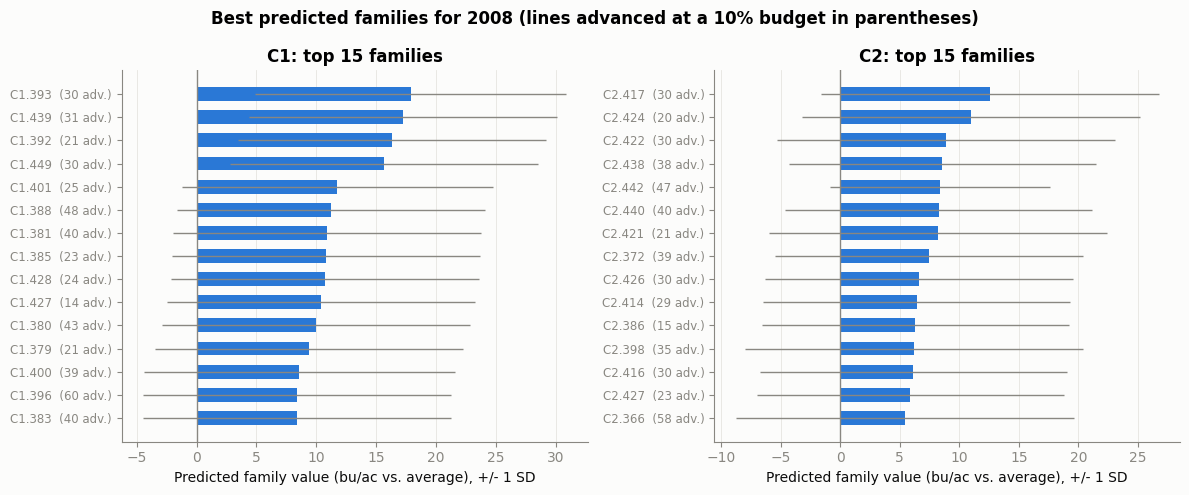

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, c in zip(axes, ['C1', 'C2']):
    f = F[F.CLUSTER == c].sort_values('FAMILY_PRED').tail(15)
    y = np.arange(len(f))
    ax.barh(y, f.FAMILY_PRED, color=COLORS[0], height=0.6)
    ax.errorbar(f.FAMILY_PRED, y, xerr=f.FAMILY_SD, fmt='none', ecolor=MUTED, elinewidth=1, capsize=0)
    ax.set_yticks(y); ax.set_yticklabels([f'{p}  ({n} adv.)' for p, n in zip(f.POP, f.N_ADVANCE_10PCT)], fontsize=8.5)
    ax.axvline(0, color=MUTED, lw=1); ax.set_xlabel('Predicted family value (bu/ac vs. average), +/- 1 SD')
    ax.set_title(f'{c}: top 15 families'); ax.grid(axis='y', visible=False)
plt.suptitle('Best predicted families for 2008 (lines advanced at a 10% budget in parentheses)', fontweight='bold')
plt.tight_layout(); plt.show()

### Did it work? Scoring the 2008 decision with the answer key

In [13]:
rows = []
for c, g in K.groupby('CLUSTER'):
    mu = g.YLD_OBS_BLUE.mean()
    for share, col in [(0.05, 'ADVANCE_5PCT'), (0.10, 'ADVANCE_10PCT'), (0.20, 'ADVANCE_20PCT')]:
        sel = g[g[col]]
        true_top = g.nlargest(int(round(0.10 * len(g))), 'YLD_OBS_BLUE').index
        rows.append({'cluster': c, 'plots kept': f'{int(share*100)}%', 'lines advanced': len(sel),
                     'families kept': sel.POP.nunique(),
                     'advanced lines vs average (bu/ac)': round(sel.YLD_OBS_BLUE.mean() - mu, 1),
                     'share of true top-10% lines caught': round(len(set(sel.index) & set(true_top)) / len(true_top), 2)})
pd.DataFrame(rows)

,cluster,plots kept,lines advanced,families kept,advanced lines vs average (bu/ac),share of true top-10% lines caught
0,C1,5%,372,21,10.0,0.14
1,C1,10%,740,21,9.1,0.26
2,C1,20%,1486,21,8.2,0.51
3,C2,5%,426,26,16.5,0.14
4,C2,10%,851,26,15.2,0.25
5,C2,20%,1709,26,13.8,0.43


## 8. Business value

The course deck gives about **$150 per hybrid per location** for early yield trials. In this data each line is tested at about 6 to 7 sites.

In [14]:
COST, SITES = 150, 6.6          # $/hybrid/location (course deck, slide 36); sites per line (Stage 1 data)
n = len(R)
full = n * SITES * COST
for share in (0.10, 0.20):
    print(f'Advance {int(share*100)}%: test {int(n*share):,} of {n:,} lines -> save about ${full*(1-share)/1e6:.1f}M of ${full/1e6:.1f}M in trial costs')

Advance 10%: test 1,596 of 15,968 lines -> save about $14.2M of $15.8M in trial costs
Advance 20%: test 3,193 of 15,968 lines -> save about $12.6M of $15.8M in trial costs


Pair that with the table above. Keeping 20% of the plots catches about half of the truly best lines (51% in C1, 43% in C2), where random picks would catch 20%. The advanced lines also yield clearly above average (+8 to +14 bu/ac). The course's "skip preliminary trials" question (slides 39 to 42) is exactly this trade-off.

## 9. Limitations and next steps

- **Noisy truth.** Observed line values are about 45% signal within families, so every score here understates true accuracy.
- **Family effects are tangled with sites.** Most sites test one family, which caps how well family values can be measured and predicted.
- **Imputation.** Progeny were genotyped at only 49 to 123 markers; the rest are inferred from the parents.
- **Environment.** Weather and soil barely change which lines win (see `Envirotype_Analysis.ipynb`), so the model predicts broad performance. A north vs. south adaptation score is a possible add-on.
- **Moisture** is predicted very accurately (family-level r of about 0.75 to 0.84 in 2008). A yield-plus-moisture index is an easy next step for Challenge 3. Note that the top C2 lines are predicted to be wetter than average (`MST_PRED` of about +3.5 to +4.5), which a breeder may want to weigh.
- **Next model upgrades:** a full GBLUP or Bayesian model with a relationship matrix, a haplotype HMM for imputation, and joint yield-plus-moisture selection.